In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pickle
import json

from pylab import *

In [3]:
from utilities import phase_unwrap_from_I, norm_I

# Target Experiment to be processed (experiment)

In [4]:
experiment = 'experiment_2_linear_Voltage'  # user: set folder name under calibration_data_path_root

## Import all data:

In [5]:
_config = json.loads((Path('..') / 'config' / 'paths.json').read_text(encoding='utf-8'))
calibration_data_path_root = Path(_config['calibration_data_path_root'])
LUT_path_root = Path(_config['LUT_path_root'])


In [6]:
data_dir = calibration_data_path_root / experiment
pkl_files = sorted(data_dir.glob('*.pkl'))

data = {}
for idx, pkl_path in enumerate(pkl_files):
    with open(pkl_path, 'rb') as f:
        data[idx] = pickle.load(f)

print(f'Loaded {len(data)} pkl(s) from:\n  {data_dir}')


Loaded 1 pkl(s) from:
  C:\Users\ModeLabQBI\LAB\experiments\calibrations\Meadowlark_LUT\data\cam_pol_interference\experiment_2_linear_Voltage


### All interferograms:
### Visualized them and get the unwrap phase:

In [7]:
interferograms = []
unwrapped_phase = []
interferograms_dict = {}
for key, item in data.items():
    for key2, item2 in item.items():
        interferograms_dict[key2] = {}
        for key3, item3 in item2.items():
            interferograms_dict[key2][key3] = item3
            interferograms.append(item3)
            unwrapped_phase.append(phase_unwrap_from_I(item3, filter = False))

In [8]:
len(interferograms)

4

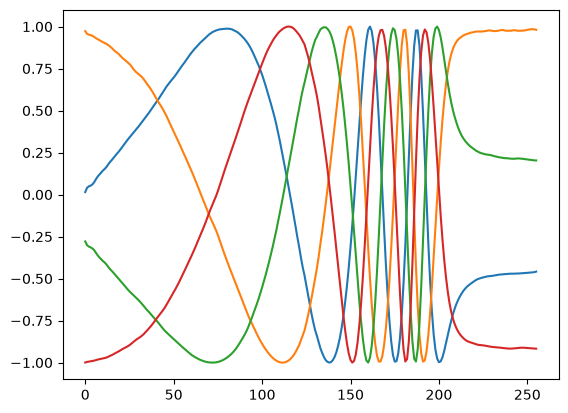

In [9]:
for line in interferograms:
    plot(norm_I(line))

In [10]:
from scipy.signal import hilbert, find_peaks
from scipy.signal.windows import hann


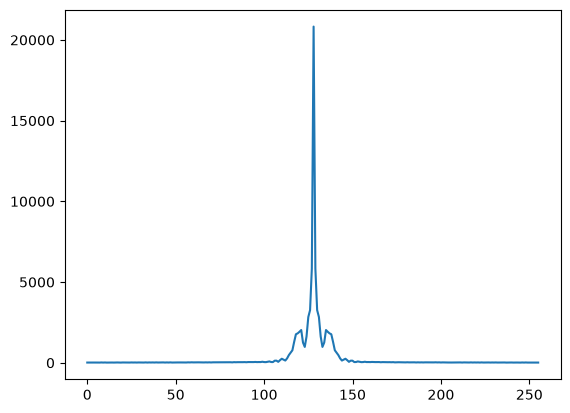

In [13]:
I_x = interferograms[0]

fft_Ix = fftshift(fft(I_x))
plot(abs(fft_Ix))

### We use the mean of all the sub-acquiered experiments as "real slm voltage-phase response"

In [15]:
unwrapped_phase_av = mean(array(unwrapped_phase), axis = 0)
phase_av_cycles_wraps = unwrapped_phase_av / (2*pi) 


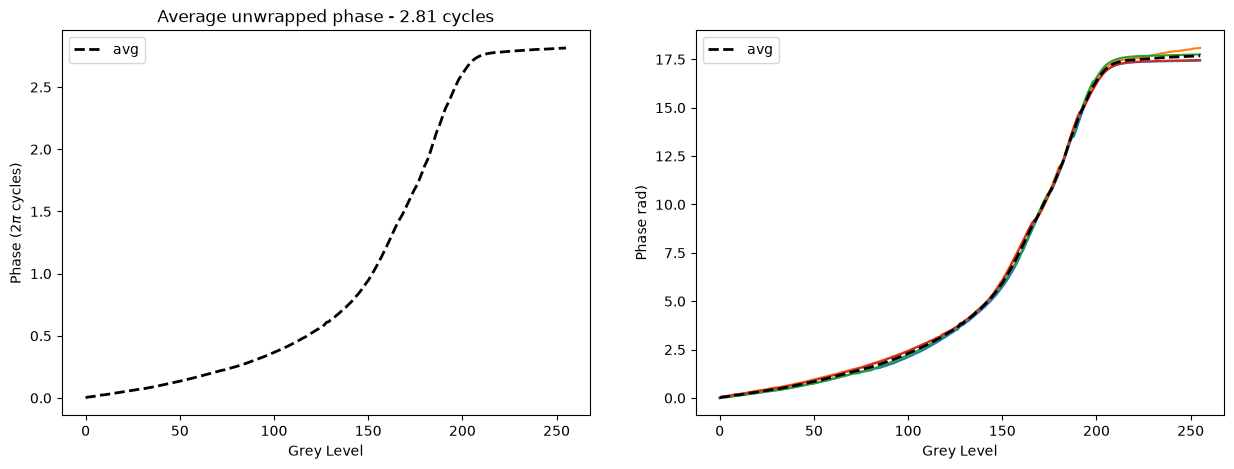

In [16]:
fig, ax = plt.subplots(1,2, figsize = (15,5))
ax[0].plot(phase_av_cycles_wraps,'--', color = 'black', label = 'avg', linewidth = 2)
ax[0].set_title(f'Average unwrapped phase - {phase_av_cycles_wraps.max():0.2f} cycles')
ax[0].set_xlabel('Grey Level')
ax[0].set_ylabel('Phase (2$\pi$ cycles)')
ax[0].legend()

for line in unwrapped_phase:
    ax[1].plot(line)
ax[1].plot(unwrapped_phase_av, '--', color = 'black', label = 'avg', linewidth = 2)
ax[1].set_xlabel('Grey Level')
ax[1].set_ylabel('Phase rad)')
ax[1].legend()

# Analysis:

In [17]:
from scipy.interpolate import UnivariateSpline


### Measured: $\phi(V)$ for V linearly space function from 0 to 2027 with 256 samples
### Target: $V(\phi)$ for $\phi$ linearly space function from 0 to 2pi with 256 samples

In [18]:
voltageDriver = linspace(0,2047,256)

phase_fit_spl = UnivariateSpline(voltageDriver, phase_av_cycles_wraps, k=3, s=0)
phase_fit_spl.set_smoothing_factor(0.01)
unwrapped_phase_fit = phase_fit_spl(voltageDriver) #we can use this one as it will reduce noise

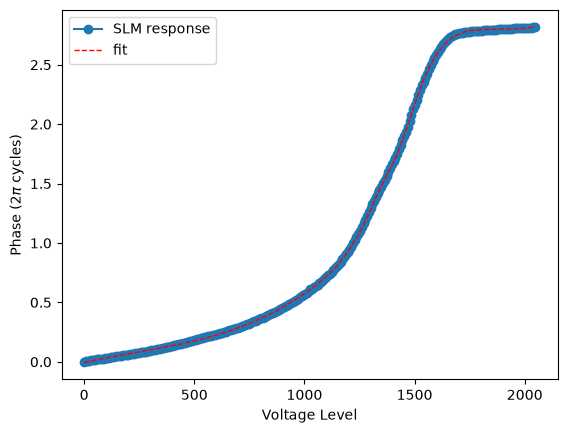

In [69]:
plot( voltageDriver, phase_av_cycles_wraps,'-o', label='SLM response')
plot(voltageDriver, unwrapped_phase_fit, '--', color = 'red', label = 'fit', linewidth = 1)
ylabel('Phase (2$\pi$ cycles)')
xlabel('Voltage Level')
legend()


In [35]:
start_phase_cycle = 0.1
buffer_region_fit_in_samples = 10

In [36]:
phase_region = linspace(start_phase_cycle, start_phase_cycle + 1, 256)

# Do not invert the whole response, only the region of interest + a buffer
phase_start = phase_region[0]
phase_end = phase_region[-1]
phase_start_idx = np.where(unwrapped_phase_fit >= phase_start)[0][0]
phase_end_idx = np.where(unwrapped_phase_fit <= phase_end)[0][-1]

phase_av_cycles_wraps_cropped = unwrapped_phase_fit[phase_start_idx - buffer_region_fit_in_samples:phase_end_idx + buffer_region_fit_in_samples] 
voltageDriver_cropped = voltageDriver[phase_start_idx - buffer_region_fit_in_samples:phase_end_idx + buffer_region_fit_in_samples] 


In [37]:
voltage_spl = UnivariateSpline( phase_av_cycles_wraps_cropped, voltageDriver_cropped, k=3, s=0)
voltage_spl.set_smoothing_factor(0.0) # We already filtered the noise via first spline fit phi(V)


In [38]:
driver_voltage_level_LUT = around(voltage_spl(phase_region)).astype(int) #Calculate the LUT

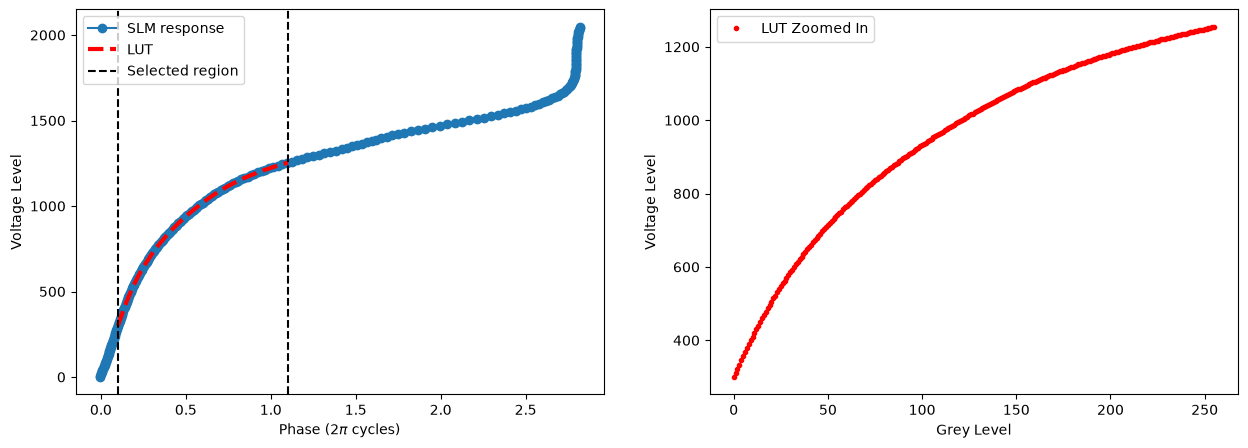

In [39]:
fig, ax = plt.subplots(1,2, figsize = (15,5))
ax[0].plot(unwrapped_phase_fit, voltageDriver,'-o', label='SLM response')
ax[0].plot( phase_region, driver_voltage_level_LUT, '--', color = 'red', label = 'LUT', linewidth = 3)
ax[0].set_xlabel('Phase (2$\pi$ cycles)')
ax[0].set_ylabel('Voltage Level')

ax[0].vlines(phase_start, 0, 1, transform=ax[0].get_xaxis_transform(), color='black', linestyle='--', label = 'Selected region')
ax[0].vlines(phase_end, 0, 1, transform=ax[0].get_xaxis_transform(), color='black', linestyle='--')

ax[0].legend()

ax[1].plot(driver_voltage_level_LUT, '.', color = 'red', label = 'LUT Zoomed In', linewidth = 3)
ax[1].set_xlabel('Grey Level')
ax[1].set_ylabel('Voltage Level')

ax[1].legend()


In [28]:
LUT_path_root.mkdir(parents=True, exist_ok=True)

LUT_NAME = f'SLM_QBI_AR_843_5nm_cover_glass_6_2V_start_phase_{start_phase_cycle}_no_smoothing.lut'  # user: set filename
path_to_save = LUT_path_root / LUT_NAME
print(path_to_save)


C:\Users\ModeLabQBI\LAB\experiments\calibrations\Meadowlark_LUT\data\LUTs\SLM_QBI_AR_843_5nm_cover_glass_6_2V_start_phase_0_no_smoothing.lut


In [29]:
lut = np.column_stack((np.arange(256, dtype=int), np.asarray(driver_voltage_level_LUT)))
np.savetxt(path_to_save, lut, fmt='%d\t%d')

In [116]:
driver_voltage_level_LUT.shape

(256,)

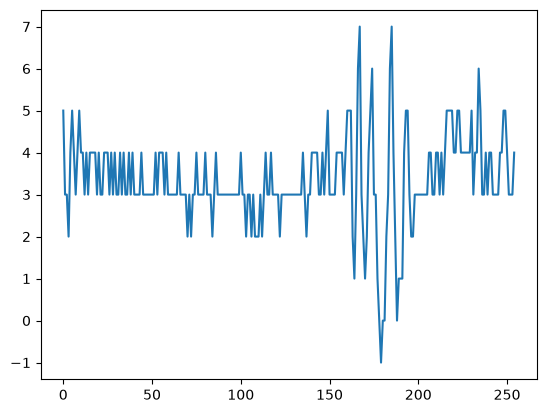

In [174]:
plot(diff(driver_voltage_level_LUT))